# NB13 — Ejemplos visuales de mamografía por categoría BI-RADS

Notebook añadido en Hito 3 a petición de la tutora (punto 5 del feedback).

Genera una figura de 5 paneles con ejemplos reales del propio dataset VinDr-Mammo, uno por cada categoría BI-RADS (1-5). Para las categorías sospechosas (4 y 5), se superpone el bounding box del hallazgo anotado por los radiólogos.

La figura resultante acompaña a la sección 3.1.3 de la memoria (sistema BI-RADS) y sirve para ilustrar el aspecto radiológico típico de cada categoría de sospecha en las mismas condiciones de cohorte que el trabajo (cohorte vietnamita, resoluciones típicas 3518×2800 y 3062×2394).


## 1. Setup y paths


In [1]:
import os
import numpy as np
import pandas as pd
import pydicom
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Raíz del proyecto (mismo esquema que el resto de notebooks)
BASE      = os.environ.get('TFM_PROJECT_ROOT',
                           os.path.abspath(os.path.join(os.getcwd(), '..')))
DATA      = os.path.join(BASE, 'Data', 'vindr-mammo')
IMG_DIR   = os.path.join(DATA, 'images')
BREAST_CSV  = os.path.join(DATA, 'breast-level_annotations.csv')
FINDING_CSV = os.path.join(DATA, 'finding_annotations.csv')
OUT_DIR   = os.path.join(BASE, 'outputs', 'Features')
os.makedirs(OUT_DIR, exist_ok=True)

print(f'BASE:    {BASE}')
print(f'IMG_DIR: {IMG_DIR}')


BASE:    c:\Users\victo\Documents\TFM\Proyecto
IMG_DIR: c:\Users\victo\Documents\TFM\Proyecto\Data\vindr-mammo\images


## 2. Cargar anotaciones y seleccionar ejemplos

Se elige una vista **CC** representativa para cada categoría BI-RADS (1-5). Para las categorías 4 y 5 se selecciona una vista con **bounding box del hallazgo** disponible en `finding_annotations.csv`.


In [2]:
breast = pd.read_csv(BREAST_CSV)
finding = pd.read_csv(FINDING_CSV)

def parse_birads(v):
    if isinstance(v, str):
        return int(v.replace('BI-RADS', '').strip())
    return int(v) if not pd.isna(v) else None

breast['birads_num'] = breast['breast_birads'].apply(parse_birads)
finding['birads_num'] = finding['breast_birads'].apply(parse_birads)

# Semilla para reproducibilidad de la selección
np.random.seed(42)

# Para BI-RADS 1-3: elegir la primera vista CC disponible
# Para BI-RADS 4-5: elegir la primera con bounding box en finding_annotations
ejemplos = []
for b in [1, 2, 3, 4, 5]:
    if b <= 3:
        cand = breast[(breast.birads_num == b) & (breast.view_position == 'CC')].reset_index(drop=True)
        row = cand.iloc[0]
        ejemplos.append({
            'birads': b,
            'image_id': row['image_id'],
            'study_id': row['study_id'],
            'laterality': row['laterality'],
            'view': row['view_position'],
            'density': row['breast_density'].replace('DENSITY ', ''),
            'bbox': None,
        })
    else:
        cand = finding[(finding.birads_num == b) & (finding.view_position == 'CC') & 
                        finding['xmin'].notna()].reset_index(drop=True)
        row = cand.iloc[0]
        ejemplos.append({
            'birads': b,
            'image_id': row['image_id'],
            'study_id': row['study_id'],
            'laterality': row['laterality'],
            'view': row['view_position'],
            'density': row['breast_density'].replace('DENSITY ', ''),
            'bbox': (row['xmin'], row['ymin'], row['xmax'], row['ymax']),
            'finding_cat': row['finding_categories'],
        })

print('Ejemplos seleccionados:')
print(f'{"BI-RADS":<10}{"Lat":<5}{"Vista":<7}{"Dens":<6}{"BBox":<8}{"Study ID (first 12)"}')
print('─' * 65)
for e in ejemplos:
    has_bbox = '✓' if e['bbox'] is not None else '—'
    print(f'{e["birads"]:<10}{e["laterality"]:<5}{e["view"]:<7}{e["density"]:<6}{has_bbox:<8}{e["study_id"][:12]}...')


Ejemplos seleccionados:
BI-RADS   Lat  Vista  Dens  BBox    Study ID (first 12)
─────────────────────────────────────────────────────────────────
1         L    CC     C     —       8269f5971eac...
2         L    CC     C     —       b8d273e8601f...
3         L    CC     C     —       cca141f804a8...
4         R    CC     C     ✓       48575a27b7c9...
5         L    CC     C     ✓       57674c2def92...


## 3. Función de carga DICOM para visualización

Preparación mínima para mostrar la imagen: leer DICOM, aplicar RescaleSlope/Intercept, Window/Level e invertir MONOCHROME1 si es necesario. **No** se aplica alineación por centroide ni redimensionado — queremos mostrar la mamografía tal como la vería el radiólogo.


In [3]:
def load_dicom_for_display(dcm_path):
    """Carga un DICOM y aplica preparación mínima para visualización.
    
    NO alinea ni redimensiona: queremos ver la mamografía en su tamaño original.
    """
    ds = pydicom.dcmread(dcm_path)
    px = ds.pixel_array.astype(np.float32)
    px = px * float(getattr(ds, 'RescaleSlope', 1)) + float(getattr(ds, 'RescaleIntercept', 0))
    
    if hasattr(ds, 'WindowCenter') and hasattr(ds, 'WindowWidth'):
        wc = float(ds.WindowCenter[0]) if hasattr(ds.WindowCenter, '__iter__') else float(ds.WindowCenter)
        ww = float(ds.WindowWidth[0])  if hasattr(ds.WindowWidth,  '__iter__') else float(ds.WindowWidth)
        px = np.clip(px, wc-ww/2, wc+ww/2)
    
    if getattr(ds, 'PhotometricInterpretation', '') == 'MONOCHROME1':
        px = px.max() - px
    
    return px

print('Función load_dicom_for_display definida.')


Función load_dicom_for_display definida.


## 4. Figura 1×5 con los ejemplos

Para cada categoría BI-RADS se muestra la vista CC seleccionada. En las categorías 4 y 5 se superpone el bounding box del hallazgo (`finding_annotations.csv`) para señalar la región sospechosa.


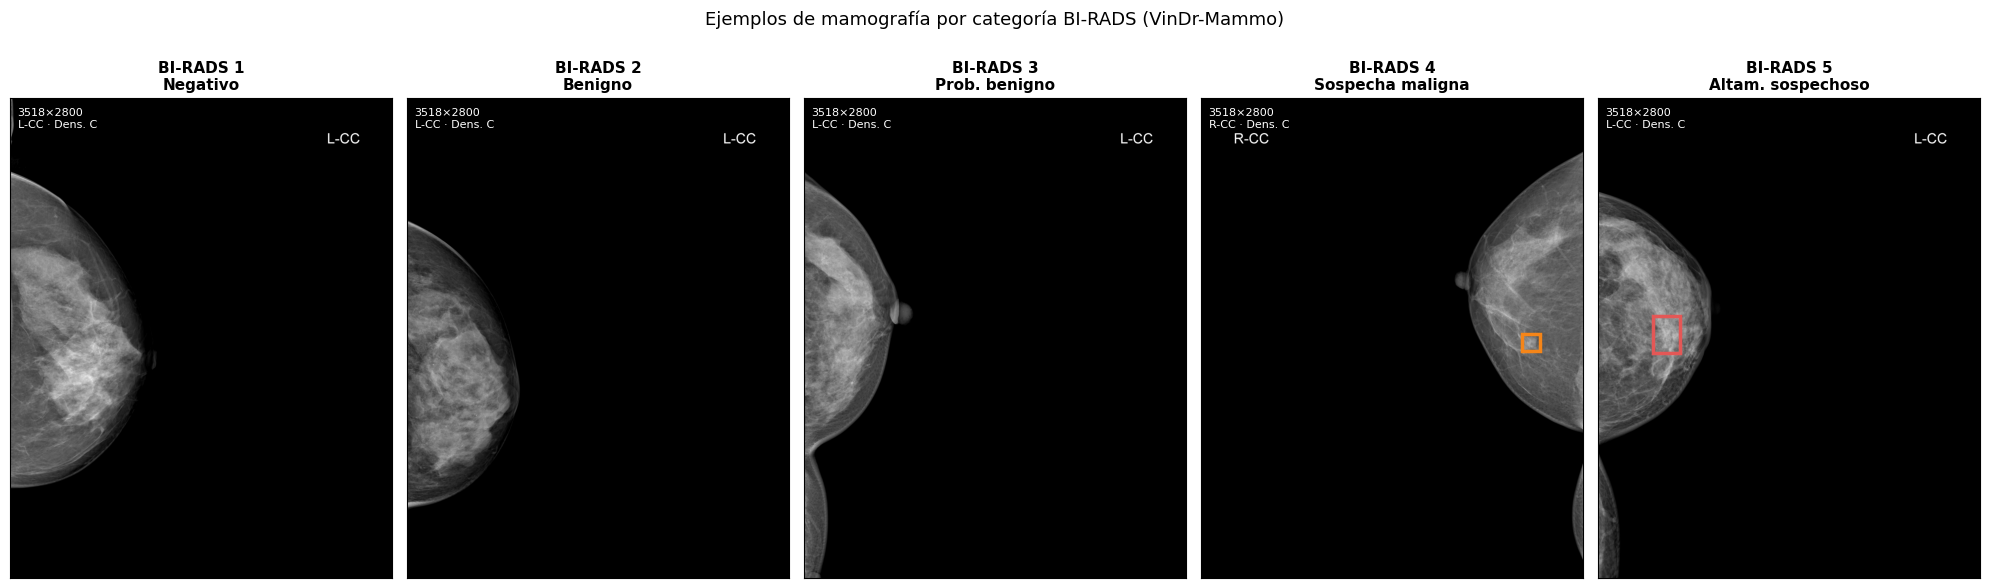


Guardado: c:\Users\victo\Documents\TFM\Proyecto\outputs\Features\ejemplos_birads.png


In [4]:
# Ubicación estándar VinDr-Mammo: images/{study_id}/{image_id}.dicom
def _dcm_path(study_id, image_id):
    return os.path.join(IMG_DIR, study_id, f'{image_id}.dicom')

# Estilos por categoría (colores basados en el forest plot de BI-RADS)
_bir_titulos = {
    1: 'BI-RADS 1\nNegativo',
    2: 'BI-RADS 2\nBenigno',
    3: 'BI-RADS 3\nProb. benigno',
    4: 'BI-RADS 4\nSospecha maligna',
    5: 'BI-RADS 5\nAltam. sospechoso',
}
_bbox_color = {4: '#f58518', 5: '#e45756'}

fig, axes = plt.subplots(1, 5, figsize=(20, 6))
for ax, e in zip(axes, ejemplos):
    path = _dcm_path(e['study_id'], e['image_id'])
    if not os.path.exists(path):
        ax.text(0.5, 0.5, f'DICOM no encontrado:\n{path[-40:]}',
                ha='center', va='center', transform=ax.transAxes, fontsize=8)
        ax.set_title(_bir_titulos[e['birads']], fontsize=11, fontweight='bold')
        ax.axis('off')
        continue
    
    img = load_dicom_for_display(path)
    ax.imshow(img, cmap='gray', aspect='equal')
    
    # Bounding box para BI-RADS 4 y 5
    if e['bbox'] is not None:
        xmin, ymin, xmax, ymax = e['bbox']
        rect = patches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin,
                                 linewidth=2.5, edgecolor=_bbox_color[e['birads']],
                                 facecolor='none')
        ax.add_patch(rect)
    
    ax.set_title(_bir_titulos[e['birads']], fontsize=11, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    
    # Anotación: shape + laterality/densidad
    txt = f'{img.shape[0]}×{img.shape[1]}\n{e["laterality"]}-{e["view"]} · Dens. {e["density"]}'
    ax.text(0.02, 0.98, txt, transform=ax.transAxes,
            fontsize=8, va='top', ha='left', color='white',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7, edgecolor='none'))

fig.suptitle('Ejemplos de mamografía por categoría BI-RADS (VinDr-Mammo)',
             fontsize=13, y=1.02)
plt.tight_layout()

_out_path = os.path.join(OUT_DIR, 'ejemplos_birads.png')
plt.savefig(_out_path, dpi=140, bbox_inches='tight')
plt.show()
print(f'\nGuardado: {_out_path}')


## Nota

Los recuadros de colores señalan la localización de los hallazgos anotados por los radiólogos de VinDr-Mammo en las categorías sospechosas (naranja para BI-RADS 4, rojo para BI-RADS 5). En las categorías 1-3 no hay hallazgos anotados por definición (BI-RADS 1 = negativo, 2 = benigno, 3 = probablemente benigno), por lo que no hay bounding box que mostrar.
